# Piezo-Beam Torch FE Analysis (Differentiable)

This notebook mirrors the FE workflow using `Modeling.models_torch` instead of `Modeling.models.FE3`.

What this notebook provides:
- Differentiable assembly of reduced `K`, `M`, and `Gamma`
- Generalized eigen-analysis for natural frequencies
- Gradient extraction with respect to design/material parameters
- Modal FRF-style velocity estimate for frequency sweeps
- **Arbitrary region geometry** via `build_geometry_from_types`

The region API matches the FE3-style pattern: define `region_types`, `region_sequence`, and `x_starts`, then pass the resulting geometry into `PiezoBeamFE_Torch` as `geometry=...`.

In [55]:
import sys
import importlib
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

# Find workspace root containing Modeling/ and add to sys.path
cwd = Path.cwd().resolve()
project_root = next((p for p in [cwd, *cwd.parents] if (p / "Modeling").exists()), None)
if project_root is None:
    raise RuntimeError("Could not find workspace root containing Modeling/.")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import Modeling.models_torch.beam_params_torch as bp_torch_mod
import Modeling.models_torch.fe_torch as fe_torch_mod
import Modeling.models_torch.fe_helpers_compat as compat_mod
from Modeling.models.beam_properties import PiezoBeamParams
import Modeling.models.FE3 as FE3_module
from Modeling.models import FE_helpers

importlib.reload(bp_torch_mod)
importlib.reload(fe_torch_mod)
importlib.reload(compat_mod)
importlib.reload(FE3_module)
importlib.reload(FE_helpers)

PiezoBeamParamsTorch = bp_torch_mod.PiezoBeamParamsTorch
PiezoBeamFE_Torch = fe_torch_mod.PiezoBeamFE_Torch
build_geometry_from_types = fe_torch_mod.build_geometry_from_types
build_ode_system_compat = compat_mod.build_ode_system_compat

torch.set_default_dtype(torch.float64)
print(f"Using project root: {project_root}")

Using project root: C:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\Metamaterial beam


In [56]:
# ------------------------------------------------------------
# Parameter setup (aligned with the original FE3 notebook)
# and arbitrary region layout via build_geometry_from_types
# ------------------------------------------------------------
L = 0.3
b_s = 100e-3
b_p = 14e-3
b_k = 25e-3
h_s = 0.5e-3
h_p = 0.12e-3
h_k = 0.2e-3
rho_s = 1190.0
rho_p = 7800.0
rho_k = 1420.0
E_s = 3e9
E_p = 31e9
E_k = 3e9
d31 = -1.48e-10
eps_r = 1700.0

# Use the same modal damping dictionary as FE3 defaults
params_ref = PiezoBeamParams()
params_ref.zeta_p = 0.05
params_ref.zeta_q = 0.2
zeta_dict = dict(params_ref.zeta_dict)

def compute_EI_and_rhoA(E_layers, rho_layers, h_layers, b_layers):
    E_layers = np.asarray(E_layers, dtype=float)
    rho_layers = np.asarray(rho_layers, dtype=float)
    h_layers = np.asarray(h_layers, dtype=float)
    b_layers = np.asarray(b_layers, dtype=float)
    if not (len(E_layers) == len(rho_layers) == len(h_layers) == len(b_layers)):
        raise ValueError("Layer arrays must have the same length.")

    y = [h_layers[0] / 2]
    for i in range(1, len(h_layers)):
        y.append(y[i - 1] + h_layers[i])

    EI = 0.0
    rhoA = 0.0
    for i, (E, b) in enumerate(zip(E_layers, b_layers)):
        if i == 0:
            EI += E * b * y[i] ** 3 / 3.0
            rhoA += rho_layers[i] * b * h_layers[i] / 2.0
        else:
            EI += E * b * (y[i] ** 3 - y[i - 1] ** 3) / 3.0
            rhoA += rho_layers[i] * b * h_layers[i]
    return 2.0 * EI, 2.0 * rhoA

EI_kapton, rhoA_kapton = compute_EI_and_rhoA(
    E_layers=[E_s, E_k],
    rho_layers=[rho_s, rho_k],
    h_layers=[h_s, h_k],
    b_layers=[b_s, b_k],
)
EI_piezo, rhoA_piezo = compute_EI_and_rhoA(
    E_layers=[E_s, E_k, E_p],
    rho_layers=[rho_s, rho_k, rho_p],
    h_layers=[h_s, h_k, h_p],
    b_layers=[b_s, b_k, b_p],
)

rhoA_substrate = b_s * rho_s * h_s
EI_substrate = b_s * E_s * h_s ** 3 / 12.0

region_types = {
    "substrate": {"EI": EI_substrate, "rhoA": rhoA_substrate, "h": 1e-3},
    "piezo": {"EI": EI_piezo, "rhoA": rhoA_piezo, "h": 5e-3},
    "kapton": {"EI": EI_kapton, "rhoA": rhoA_kapton, "h": 1e-3},
}
region_sequence = [
    "kapton", "piezo", "kapton", "substrate",
    "kapton", "piezo", "kapton", "substrate",
    "kapton", "piezo", "kapton", "substrate",
    "kapton", "piezo", "kapton", "substrate",
    "kapton", "piezo", "kapton", "substrate",
]
unit_cell = np.array([0, 4.5, 32.5, 37.0]) * 1e-3
x_starts = np.concatenate([unit_cell + i * 40e-3 for i in range(5)])

geom = build_geometry_from_types(
    L=L,
    region_types=region_types,
    region_sequence=region_sequence,
    x_starts=x_starts,
    default_h=1e-3,
)

tp = PiezoBeamParamsTorch(dtype=torch.float64)
with torch.no_grad():
    tp.hp.copy_(torch.tensor(h_p, dtype=tp.hp.dtype))
    tp.hs.copy_(torch.tensor(h_s, dtype=tp.hs.dtype))
    tp.b.copy_(torch.tensor(b_s, dtype=tp.b.dtype))
    tp.E_s.copy_(torch.tensor(E_s, dtype=tp.E_s.dtype))
    tp.s11.copy_(torch.tensor(1.0 / E_p, dtype=tp.s11.dtype))
    tp.rho_s.copy_(torch.tensor(rho_s, dtype=tp.rho_s.dtype))
    tp.rho_p.copy_(torch.tensor(rho_p, dtype=tp.rho_p.dtype))
    tp.d31.copy_(torch.tensor(d31, dtype=tp.d31.dtype))
    tp.eps_r.copy_(torch.tensor(eps_r, dtype=tp.eps_r.dtype))

n_elem = len(geom.elem_EI)
x_nodes = np.asarray(geom.x_nodes, dtype=float)
x_mid = 0.5 * (x_nodes[:-1] + x_nodes[1:])

# Build per-element region labels to map differentiable properties by type
region_labels = []
x_starts_np = np.asarray(x_starts, dtype=float)
for xm in x_mid:
    idx = np.searchsorted(x_starts_np, xm, side="right") - 1
    idx = int(np.clip(idx, 0, len(region_sequence) - 1))
    region_labels.append(region_sequence[idx])

mask_sub = torch.tensor([lbl == "substrate" for lbl in region_labels], dtype=torch.bool)
mask_pie = torch.tensor([lbl == "piezo" for lbl in region_labels], dtype=torch.bool)
mask_kap = torch.tensor([lbl == "kapton" for lbl in region_labels], dtype=torch.bool)

# Constants for kapton-containing regions; gradients still flow through tp terms
E_k_t = torch.tensor(E_k, dtype=tp.dtype)
rho_k_t = torch.tensor(rho_k, dtype=tp.dtype)
b_k_t = torch.tensor(b_k, dtype=tp.dtype)
h_k_t = torch.tensor(h_k, dtype=tp.dtype)

def layered_EI_rhoA_torch(E_layers, rho_layers, h_layers, b_layers):
    y = [h_layers[0] / 2.0]
    for i in range(1, len(h_layers)):
        y.append(y[i - 1] + h_layers[i])

    EI = torch.zeros((), dtype=tp.dtype)
    rhoA = torch.zeros((), dtype=tp.dtype)
    for i, (E_i, b_i) in enumerate(zip(E_layers, b_layers)):
        if i == 0:
            EI = EI + E_i * b_i * y[i] ** 3 / 3.0
            rhoA = rhoA + rho_layers[i] * b_i * h_layers[i] / 2.0
        else:
            EI = EI + E_i * b_i * (y[i] ** 3 - y[i - 1] ** 3) / 3.0
            rhoA = rhoA + rho_layers[i] * b_i * h_layers[i]
    return 2.0 * EI, 2.0 * rhoA

def elem_property_fn(tp_local):
    E_p_t = 1.0 / tp_local.s11

    EI_sub = tp_local.b * tp_local.E_s * tp_local.hs ** 3 / 12.0
    rhoA_sub = tp_local.b * tp_local.rho_s * tp_local.hs

    EI_kap, rhoA_kap = layered_EI_rhoA_torch(
        E_layers=[tp_local.E_s, E_k_t],
        rho_layers=[tp_local.rho_s, rho_k_t],
        h_layers=[tp_local.hs, h_k_t],
        b_layers=[tp_local.b, b_k_t],
    )

    EI_pie, rhoA_pie = layered_EI_rhoA_torch(
        E_layers=[tp_local.E_s, E_k_t, E_p_t],
        rho_layers=[tp_local.rho_s, rho_k_t, tp_local.rho_p],
        h_layers=[tp_local.hs, h_k_t, tp_local.hp],
        b_layers=[tp_local.b, b_k_t, torch.tensor(b_p, dtype=tp_local.dtype)],
    )

    EI_vec = torch.empty((n_elem,), dtype=tp_local.dtype)
    rhoA_vec = torch.empty((n_elem,), dtype=tp_local.dtype)
    EI_vec = torch.where(mask_sub, EI_sub, EI_vec)
    rhoA_vec = torch.where(mask_sub, rhoA_sub, rhoA_vec)
    EI_vec = torch.where(mask_kap, EI_kap, EI_vec)
    rhoA_vec = torch.where(mask_kap, rhoA_kap, rhoA_vec)
    EI_vec = torch.where(mask_pie, EI_pie, EI_vec)
    rhoA_vec = torch.where(mask_pie, rhoA_pie, rhoA_vec)
    return EI_vec, rhoA_vec

fe = PiezoBeamFE_Torch(tp, geometry=geom, elem_property_fn=elem_property_fn)
n_piezos = len(fe._mesh.piezo_node_pairs)

print("Torch FE model built (arbitrary regions + differentiable EI/rhoA).")
print(f"  n_elem:  {len(geom.elem_EI)}")
print(f"  Ndof:    {fe.K_hat.shape[1]}")
print(f"  Nfree:   {len(fe._mesh.free_dofs)}")
print(f"  S:       {n_piezos}")
print(f"  L from geometry: {geom.x_nodes[-1]:.4f} m")
print(f"zeta_dict['rest'] = {zeta_dict.get('rest')}")

Torch FE model built (arbitrary regions + differentiable EI/rhoA).
  n_elem:  199
  Ndof:    400
  Nfree:   398
  S:       5
  L from geometry: 0.3000 m
zeta_dict['rest'] = 0.4


In [49]:
# ------------------------------------------------------------
# Assemble differentiable matrices and run modal analysis
# ------------------------------------------------------------
K_red, M_red, Gamma_red = fe.build_KM_Gamma()
out = fe(n_modes=20)

freq = out['freq'].detach().cpu().numpy()

print("Shapes:")
print(f"  K_red:    {tuple(K_red.shape)}")
print(f"  M_red:    {tuple(M_red.shape)}")
print(f"  Gamma_red:{tuple(Gamma_red.shape)}")

print("\nFirst 10 natural frequencies [Hz]:")
for i, f_i in enumerate(freq[:10], start=1):
    print(f"  Mode {i:2d}: {f_i:10.4f}")

Shapes:
  K_red:    (398, 398)
  M_red:    (398, 398)
  Gamma_red:(398, 5)

First 10 natural frequencies [Hz]:
  Mode  1:     2.8282
  Mode  2:    13.5287
  Mode  3:    33.7419
  Mode  4:    69.8994
  Mode  5:   109.5693
  Mode  6:   165.0307
  Mode  7:   231.6505
  Mode  8:   281.0672
  Mode  9:   427.6873
  Mode 10:   593.2645


In [50]:
# ------------------------------------------------------------
# Autograd sensitivities of first mode frequency
# ------------------------------------------------------------
tp.zero_grad()
f1 = fe(n_modes=1)['freq'][0]

if not f1.requires_grad:
    print("f1 does not currently depend on tp parameters in this geometry mode.")
    print("Reason: arbitrary geometry was built from fixed numeric EI/rhoA.")
    print("Use default patch-gap mode (or symbolic region property mapping) for tp gradients.")
else:
    f1.backward()

    # Convert ds11 gradient to dE_p gradient using E_p = 1/s11
    E_p_t = 1.0 / tp.s11
    df_ds11 = tp.s11.grad.detach().clone() if tp.s11.grad is not None else torch.zeros_like(tp.s11)
    df_dEp = df_ds11 * (-1.0 / (E_p_t ** 2))

    def grad_or_nan(g):
        return float("nan") if g is None else g.item()

    print(f"f1 = {f1.item():.6f} Hz")
    print("Gradients:")
    print(f"  df1/dhp    = {grad_or_nan(tp.hp.grad): .6e}")
    print(f"  df1/dhs    = {grad_or_nan(tp.hs.grad): .6e}")
    print(f"  df1/dE_s   = {grad_or_nan(tp.E_s.grad): .6e}")
    print(f"  df1/dE_p   = {df_dEp.item(): .6e}   (via s11 chain rule)")
    print(f"  df1/dd31   = {grad_or_nan(tp.d31.grad): .6e}  (often ~0 for purely modal K/M)")
    print(f"  df1/drho_s = {grad_or_nan(tp.rho_s.grad): .6e}")
    print(f"  df1/drho_p = {grad_or_nan(tp.rho_p.grad): .6e}")

f1 = 2.828262 Hz
Gradients:
  df1/dhp    =  2.709564e+03
  df1/dhs    =  3.353778e+03
  df1/dE_s   =  2.364504e-10
  df1/dE_p   =  1.014080e-11   (via s11 chain rule)
  df1/dd31   =  nan  (often ~0 for purely modal K/M)
  df1/drho_s = -1.093252e-03
  df1/drho_p = -8.427312e-06


In [51]:
# ------------------------------------------------------------
# Finite-difference check for hp gradient
# ------------------------------------------------------------
if tp.hp.grad is None:
    print("Skipping FD comparison: tp.hp.grad is None in fixed EI/rhoA geometry mode.")
else:
    eps = 1e-7
    hp0 = tp.hp.item()

    analytic = tp.hp.grad.item()

    with torch.no_grad():
        tp.hp.fill_(hp0 + eps)
        f_plus = fe(n_modes=1)['freq'][0].item()

        tp.hp.fill_(hp0 - eps)
        f_minus = fe(n_modes=1)['freq'][0].item()

        tp.hp.fill_(hp0)

    fd = (f_plus - f_minus) / (2 * eps)
    rel_err = abs(fd - analytic) / (abs(analytic) + 1e-30)

    print(f"Analytic df1/dhp : {analytic: .6e}")
    print(f"FD df1/dhp       : {fd: .6e}")
    print(f"Relative error    : {rel_err:.3e}")

Analytic df1/dhp :  2.709564e+03
FD df1/dhp       :  2.577360e+03
Relative error    : 4.879e-02


In [59]:
# ------------------------------------------------------------
# FRF comparison: FE3 vs fe_torch-compat with same parameters
# ------------------------------------------------------------
j_exc = np.arange(n_piezos)
phase_exc = np.array([np.pi / 4] * n_piezos)
A_exc = np.ones(n_piezos)
weights_complex = A_exc * np.exp(1j * phase_exc)

f0, f1, n_freq = 0.1, 50.0, 500
freq_fd = np.linspace(f0, f1, n_freq)
omega_fd = 2.0 * np.pi * freq_fd

def v_exc(t):
    t_arr = np.asarray(t)
    phi = 2.0 * np.pi * (f0 + t_arr * (f1 - f0) / 1.0) * t_arr
    vals = A_exc[:, None] * np.sin(phi[None, :] + phase_exc[:, None]) if t_arr.ndim > 0 else A_exc * np.sin(phi + phase_exc)
    return vals

# ---- fe_torch through FE_helpers compatibility wrapper ----
ode_torch = build_ode_system_compat(
    fe=fe,
    j_exc=j_exc,
    R_c=1e3,
    K_p=0.0,
    K_i=0.0,
    K_c=0.0,
    v_exc=v_exc,
    freq_domain_amps=weights_complex,
    c_alpha=0.0,
    c_beta=0.0,
    zeta_dict=zeta_dict,
)
frf_torch = FE_helpers.frf_sweep(ode_torch, omega_fd)
vel_fd_torch = np.mean(np.abs(frf_torch['u_dot']), axis=1)

# ---- FE3 model with the same geometry/properties and same zeta_dict ----
params_fe3 = PiezoBeamParams(
    b=b_s,
    hp=h_p,
    hs=h_s,
    rho_s=rho_s,
    rho_p=rho_p,
    E_s=E_s,
    s11=1.0 / E_p,
    d31=d31,
    eps_r=eps_r,
    omega_p=2 * np.pi * 1,
    omega_q=2 * np.pi * 100,
)
params_fe3.zeta_p = 0.05
params_fe3.zeta_q = 0.2
params_fe3.zeta_dict = dict(zeta_dict)
params_fe3.c_alpha = 0.0
params_fe3.c_beta = 0.0

geom_fe3 = FE3_module.build_geometry_from_types(
    L=L,
    region_types=region_types,
    region_sequence=region_sequence,
    x_starts=x_starts,
)
params_fe3.geometry = geom_fe3
fe3 = FE3_module.PiezoBeamFE(params_fe3)

ode_fe3 = fe3.build_ode_system(
    j_exc=j_exc,
    R_c=1e3,
    K_p=0.0,
    K_i=0.0,
    K_c=0.0,
    v_exc=v_exc,
    freq_domain_amps=weights_complex,
)
frf_fe3 = FE_helpers.frf_sweep(ode_fe3, omega_fd)
vel_fd_fe3 = np.mean(np.abs(frf_fe3['u_dot']), axis=1)

# keep previous variable name for downstream cells
vel_fd = vel_fd_torch

ratio = vel_fd_fe3 / (vel_fd_torch + 1e-30)
print("FRF sweeps finished with shared settings.")
print(f"  zeta_dict['rest'] = {zeta_dict.get('rest')}")
print(f"  FE3/Torch ratio mean = {np.mean(ratio):.3e}")
print(f"  FE3/Torch ratio min  = {np.min(ratio):.3e}")
print(f"  FE3/Torch ratio max  = {np.max(ratio):.3e}")

FRF sweep: 100%|██████████| 500/500 [00:04<00:00, 124.25it/s]

FRF sweeps finished with shared settings.
  zeta_dict['rest'] = 0.4
  FE3/Torch ratio mean = 1.000e+00
  FE3/Torch ratio min  = 1.000e+00
  FE3/Torch ratio max  = 1.000e+00


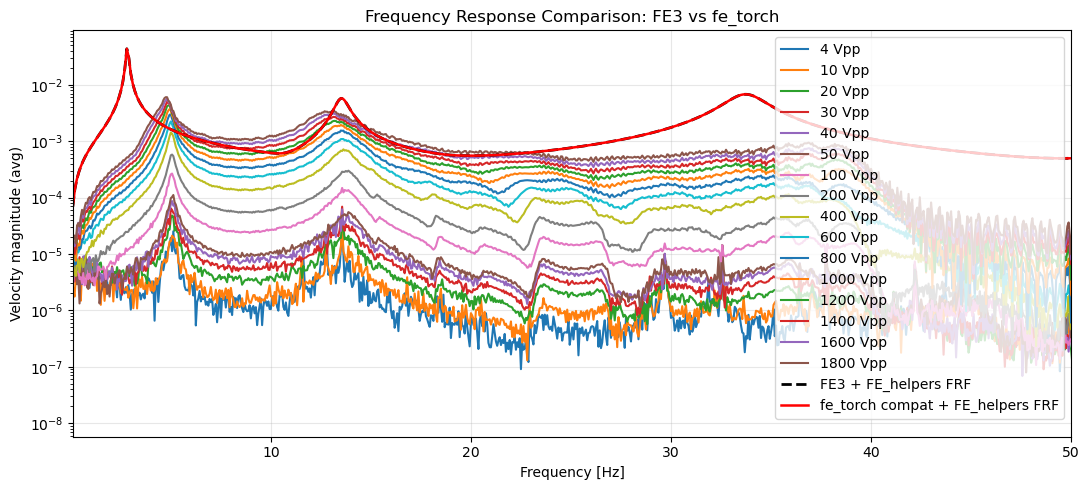

In [60]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Set your Excel file path here
excel_path = Path("./MFC1_9-28_2025.xlsx")

if not excel_path.exists():
    raise FileNotFoundError(f"Excel file not found: {excel_path.resolve()}")

xls = pd.ExcelFile(excel_path)
plt.figure(figsize=(11, 5))

for sheet_name in xls.sheet_names:
    # Read first two columns only: frequency (col 1), velocity (col 2)
    df = pd.read_excel(excel_path, sheet_name=sheet_name, usecols=[0, 1])

    # Coerce non-numeric values (headers/empty rows) to NaN and drop them
    freq = pd.to_numeric(df.iloc[:, 0], errors="coerce")
    vel = pd.to_numeric(df.iloc[:, 1], errors="coerce")
    valid = freq.notna() & vel.notna()

    if valid.any():
        plt.semilogy(freq[valid], vel[valid], lw=1.5, label=sheet_name)

plt.xlabel("Frequency [Hz]")
plt.ylabel("Velocity")
plt.title(f"Frequency vs Velocity from all sheets\n{excel_path.name}")
plt.grid(True, alpha=0.3)
plt.legend(loc="best", fontsize=8, ncol=2)
plt.tight_layout()

plt.semilogy(freq_fd, vel_fd_fe3, 'k--', lw=2.0, label='FE3 + FE_helpers FRF')
plt.semilogy(freq_fd, vel_fd_torch, 'r-', lw=1.8, label='fe_torch compat + FE_helpers FRF')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Velocity magnitude (avg)')
plt.xlim([f0, f1])
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Frequency Response Comparison: FE3 vs fe_torch')
plt.tight_layout()
plt.show()

Using experimental sheet: 1800 Vpp
Experimental resonance targets [Hz]: [ 4.75  13.125]

Optimization trace (every 20 steps):
  it=  0  loss=1.646e-01  f1=  2.828Hz  f2= 13.529Hz  hp= 0.1200mm  hs= 0.5000mm
  it= 20  loss=1.637e-01  f1=  2.834Hz  f2= 13.554Hz  hp= 0.1210mm  hs= 0.5010mm
  it= 40  loss=1.628e-01  f1=  2.840Hz  f2= 13.579Hz  hp= 0.1220mm  hs= 0.5020mm
  it= 60  loss=1.619e-01  f1=  2.846Hz  f2= 13.604Hz  hp= 0.1230mm  hs= 0.5030mm
  it= 80  loss=1.611e-01  f1=  2.852Hz  f2= 13.628Hz  hp= 0.1240mm  hs= 0.5040mm
  it=100  loss=1.603e-01  f1=  2.858Hz  f2= 13.653Hz  hp= 0.1250mm  hs= 0.5050mm
  it=120  loss=1.595e-01  f1=  2.864Hz  f2= 13.677Hz  hp= 0.1259mm  hs= 0.5059mm
  it=140  loss=1.587e-01  f1=  2.869Hz  f2= 13.700Hz  hp= 0.1269mm  hs= 0.5069mm
  it=160  loss=1.580e-01  f1=  2.875Hz  f2= 13.724Hz  hp= 0.1278mm  hs= 0.5078mm
  it=180  loss=1.572e-01  f1=  2.880Hz  f2= 13.747Hz  hp= 0.1288mm  hs= 0.5088mm
  it=200  loss=1.565e-01  f1=  2.886Hz  f2= 13.770Hz  hp= 0.1297

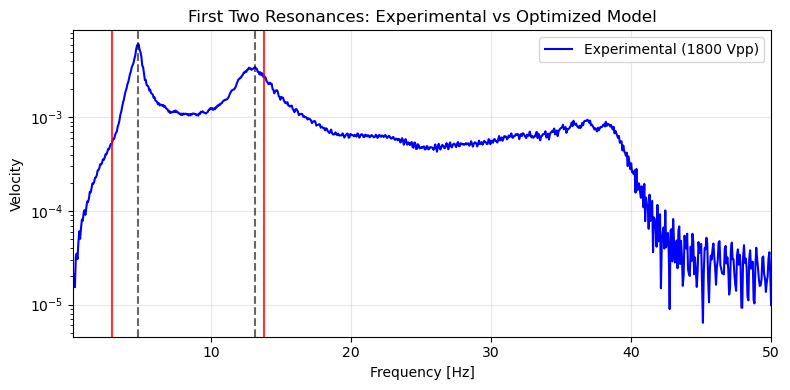

In [61]:
# ------------------------------------------------------------
# Fit parameters to match first two experimental resonances
# ------------------------------------------------------------
from scipy.signal import find_peaks

# 1) Pick an experimental sheet (prefer high SNR if available)
excel_path = Path("./MFC1_9-28_2025.xlsx")
if not excel_path.exists():
    raise FileNotFoundError(f"Excel file not found: {excel_path.resolve()}")

xls_fit = pd.ExcelFile(excel_path)
preferred_sheet = "1800 Vpp" if "1800 Vpp" in xls_fit.sheet_names else xls_fit.sheet_names[-1]
df_fit = pd.read_excel(excel_path, sheet_name=preferred_sheet, usecols=[0, 1])
f_exp_all = pd.to_numeric(df_fit.iloc[:, 0], errors="coerce").to_numpy()
v_exp_all = pd.to_numeric(df_fit.iloc[:, 1], errors="coerce").to_numpy()
mask_valid = np.isfinite(f_exp_all) & np.isfinite(v_exp_all)
f_exp_all = f_exp_all[mask_valid]
v_exp_all = v_exp_all[mask_valid]

# Restrict to comparison band and detect resonance peaks
mask_band = (f_exp_all >= f0) & (f_exp_all <= f1)
f_band = f_exp_all[mask_band]
v_band = v_exp_all[mask_band]
if len(f_band) < 10:
    raise RuntimeError("Not enough experimental points in [f0, f1] band.")

peaks, _ = find_peaks(v_band, distance=20)
if len(peaks) < 2:
    raise RuntimeError("Could not detect at least two peaks in experimental curve.")

# Pick the two highest-amplitude peaks, then sort by frequency
top2_idx = peaks[np.argsort(v_band[peaks])[-2:]]
f_exp_targets = np.sort(f_band[top2_idx])
target = torch.tensor(f_exp_targets, dtype=tp.dtype)

print(f"Using experimental sheet: {preferred_sheet}")
print(f"Experimental resonance targets [Hz]: {f_exp_targets}")

# 2) Optimize selected parameters so first two eigenfrequencies match targets
optimize_names = ["hp", "hs"]
bounds = {
    "hp": (0.05e-3, 0.5e-3),
    "hs": (0.2e-3, 1.2e-3),
}

# Freeze all params, then unfreeze selected ones
for p in tp.parameters():
    p.requires_grad_(False)
for name in optimize_names:
    getattr(tp, name).requires_grad_(True)

initial_vals = {name: getattr(tp, name).detach().clone() for name in optimize_names}
opt = torch.optim.Adam([getattr(tp, n) for n in optimize_names], lr=5e-8)

hist = []
n_steps = 220
for it in range(n_steps):
    opt.zero_grad()
    pred = fe(n_modes=2)["freq"][:2]
    rel_err = (pred - target) / target
    reg = 1e-2 * sum(((getattr(tp, n) - initial_vals[n]) / initial_vals[n]) ** 2 for n in optimize_names)
    loss = torch.sum(rel_err ** 2) + reg
    loss.backward()
    opt.step()

    with torch.no_grad():
        for n in optimize_names:
            lo, hi = bounds[n]
            getattr(tp, n).clamp_(min=lo, max=hi)

    if (it % 20 == 0) or (it == n_steps - 1):
        hist.append((it, loss.item(), pred[0].item(), pred[1].item(), tp.hp.item(), tp.hs.item()))

print("\nOptimization trace (every 20 steps):")
for rec in hist:
    it, ls, f1m, f2m, hpv, hsv = rec
    print(f"  it={it:3d}  loss={ls:.3e}  f1={f1m:7.3f}Hz  f2={f2m:7.3f}Hz  hp={hpv*1e3:7.4f}mm  hs={hsv*1e3:7.4f}mm")

with torch.no_grad():
    f_opt = fe(n_modes=2)["freq"][:2].detach().cpu().numpy()

print("\nFinal match:")
print(f"  Experimental: {f_exp_targets}")
print(f"  Model       : {f_opt}")
print(f"  Abs error   : {np.abs(f_opt - f_exp_targets)}")

# 3) Visual check on experimental curve
plt.figure(figsize=(8, 4))
plt.semilogy(f_band, v_band, 'b-', lw=1.5, label=f'Experimental ({preferred_sheet})')
for fx in f_exp_targets:
    plt.axvline(fx, color='k', ls='--', alpha=0.6)
for fm in f_opt:
    plt.axvline(fm, color='r', ls='-', alpha=0.8)
plt.xlim([f0, f1])
plt.xlabel('Frequency [Hz]')
plt.ylabel('Velocity')
plt.title('First Two Resonances: Experimental vs Optimized Model')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

`xtol` termination condition is satisfied.
Function evaluations 25, initial cost 7.7833e-02, final cost 7.7826e-02, first-order optimality 8.34e-02.

Refined fit (least_squares):
  hp*: 0.130594 mm
  hs*: 0.510571 mm
  Experimental [Hz]: [ 4.75  13.125]
  Model [Hz]      : [ 2.89165458 13.79303884]
  Abs error [Hz]  : [1.85834542 0.66803884]


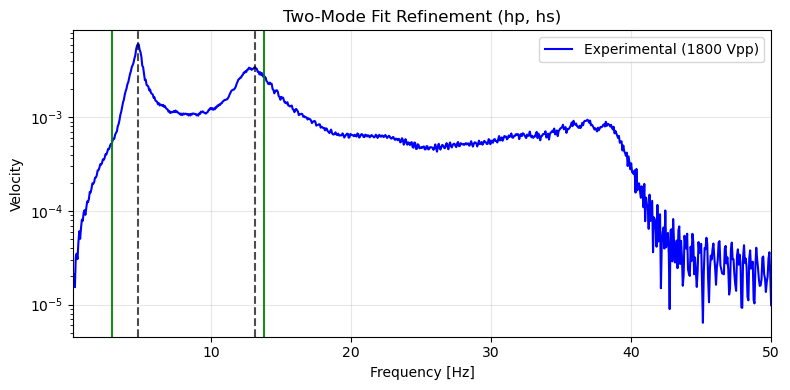

In [63]:
# ------------------------------------------------------------
# Optional refinement: direct least-squares fit on (hp, hs)
# ------------------------------------------------------------
from scipy.optimize import least_squares

target_refine = f_exp_targets.copy()

def model_first_two_freq(hp_val, hs_val):
    with torch.no_grad():
        tp.hp.fill_(hp_val)
        tp.hs.fill_(hs_val)
    f_model = fe(n_modes=2)['freq'][:2].detach().cpu().numpy()
    return f_model

def residuals_x(x):
    hp_val, hs_val = x
    f_model = model_first_two_freq(hp_val, hs_val)
    return (f_model - target_refine) / target_refine

x0 = np.array([tp.hp.item(), tp.hs.item()])
lb = np.array([0.05e-3, 0.2e-3])
ub = np.array([0.60e-3, 1.50e-3])

res = least_squares(
    residuals_x,
    x0=x0,
    bounds=(lb, ub),
    method='trf',
    xtol=1e-12,
    ftol=1e-12,
    gtol=1e-12,
    max_nfev=300,
    verbose=1,
)

hp_opt, hs_opt = res.x
f_opt_refined = model_first_two_freq(hp_opt, hs_opt)

print("\nRefined fit (least_squares):")
print(f"  hp*: {hp_opt*1e3:.6f} mm")
print(f"  hs*: {hs_opt*1e3:.6f} mm")
print(f"  Experimental [Hz]: {target_refine}")
print(f"  Model [Hz]      : {f_opt_refined}")
print(f"  Abs error [Hz]  : {np.abs(f_opt_refined - target_refine)}")

# Quick visual check
plt.figure(figsize=(8, 4))
plt.semilogy(f_band, v_band, 'b-', lw=1.5, label=f'Experimental ({preferred_sheet})')
for fx in target_refine:
    plt.axvline(fx, color='k', ls='--', alpha=0.7)
for fm in f_opt_refined:
    plt.axvline(fm, color='g', ls='-', alpha=0.9)
plt.xlim([f0, f1])
plt.xlabel('Frequency [Hz]')
plt.ylabel('Velocity')
plt.title('Two-Mode Fit Refinement (hp, hs)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [64]:
# ------------------------------------------------------------
# Parameter influence study on two-frequency mismatch
# ------------------------------------------------------------
import pandas as pd

# Use targets from previous cell if available, otherwise set manually
if 'f_exp_targets' in globals():
    f_targets = np.asarray(f_exp_targets, dtype=float)
else:
    # fallback: edit these manually if needed
    f_targets = np.array([4.75, 13.125], dtype=float)

target_t = torch.tensor(f_targets, dtype=tp.dtype)

def objective_value(freq2):
    rel = (freq2 - target_t) / target_t
    return torch.sum(rel ** 2)

# Candidate parameter subset to evaluate
candidate_names = [
    'hp', 'hs', 'b', 'E_s', 's11', 'rho_s', 'rho_p', 'd31', 'eps_r'
 ]

# Save original values
base_vals = {n: getattr(tp, n).detach().clone() for n in candidate_names}

# 1) Gradient-based local sensitivity of objective
tp.zero_grad()
for p in tp.parameters():
    p.requires_grad_(False)
for n in candidate_names:
    getattr(tp, n).requires_grad_(True)

freq_base = fe(n_modes=2)['freq'][:2]
J_base = objective_value(freq_base)
J_base.backward()

rows = []
for n in candidate_names:
    p = getattr(tp, n)
    g = p.grad.item() if p.grad is not None else 0.0
    p0 = base_vals[n].item()
    # dimensionless local influence for 1% relative perturbation
    local_effect_1pct = abs(g * (0.01 * p0))
    if n == 's11':
        # report E_p-equivalent value for readability
        Ep0 = 1.0 / p0
        rows.append({
            'param': 'E_p (via s11)',
            'base_value': Ep0,
            'grad_dJdp': g * (-1.0 / (Ep0 ** 2)),
            'local_effect_1pct': local_effect_1pct,
            'method': 'autograd'
        })
    else:
        rows.append({
            'param': n,
            'base_value': p0,
            'grad_dJdp': g,
            'local_effect_1pct': local_effect_1pct,
            'method': 'autograd'
        })

# 2) Finite-difference one-at-a-time effect (1% perturbation)
with torch.no_grad():
    for n in candidate_names:
        p = getattr(tp, n)
        p0 = base_vals[n].item()
        dp = 0.01 * abs(p0) if abs(p0) > 0 else 1e-12

        p.fill_(p0 + dp)
        J_plus = objective_value(fe(n_modes=2)['freq'][:2]).item()

        p.fill_(p0 - dp)
        J_minus = objective_value(fe(n_modes=2)['freq'][:2]).item()

        p.fill_(p0)
        fd_effect = abs(J_plus - J_minus) / 2.0

        label = 'E_p (via s11)' if n == 's11' else n
        rows.append({
            'param': label,
            'base_value': (1.0 / p0) if n == 's11' else p0,
            'grad_dJdp': np.nan,
            'local_effect_1pct': fd_effect,
            'method': 'finite-diff'
        })

# Restore original values exactly
with torch.no_grad():
    for n in candidate_names:
        getattr(tp, n).copy_(base_vals[n])

df_sens = pd.DataFrame(rows)

# Aggregate rank (use finite-diff if available, else autograd metric)
rank_df = (
    df_sens
    .sort_values(['method', 'local_effect_1pct'], ascending=[True, False])
    .reset_index(drop=True)
 )

fd_rank = (
    df_sens[df_sens['method'] == 'finite-diff']
    .sort_values('local_effect_1pct', ascending=False)
    .reset_index(drop=True)
 )

print(f"Target frequencies [Hz]: {f_targets}")
print(f"Current model frequencies [Hz]: {fe(n_modes=2)['freq'][:2].detach().cpu().numpy()}")
print(f"Current objective J: {J_base.item():.6e}")

print('\nTop parameters by finite-difference influence (1% perturbation):')
display(fd_rank[['param', 'local_effect_1pct']].head(6))

print('\nDetailed sensitivity table:')
display(rank_df)

top_subset = fd_rank['param'].head(3).tolist()
print(f"\nSuggested high-impact subset (top 3): {top_subset}")

Target frequencies [Hz]: [ 4.75  13.125]
Current model frequencies [Hz]: [ 2.89165458 13.79303884]
Current objective J: 1.556520e-01

Top parameters by finite-difference influence (1% perturbation):


,param,local_effect_1pct
0,hs,0.001962
1,rho_s,0.001771
2,b,0.000923
3,E_s,0.000821
4,hp,0.000511
5,E_p (via s11),0.000430



Detailed sensitivity table:


,param,base_value,grad_dJdp,local_effect_1pct,method
0,hs,5.105709e-04,-3.878476e+02,0.001980,autograd
1,rho_s,1.190000e+03,1.478266e-04,0.001759,autograd
2,b,1.000000e-01,9.197281e-01,0.000920,autograd
3,E_s,3.000000e+09,-2.798027e-11,0.000839,autograd
4,hp,1.305940e-04,-3.891652e+02,0.000508,autograd
5,E_p (via s11),3.100000e+10,-1.435691e-12,0.000445,autograd
6,rho_p,7.800000e+03,6.737021e-07,0.000053,autograd
7,d31,-1.480000e-10,0.000000e+00,0.000000,autograd
8,eps_r,1.700000e+03,0.000000e+00,0.000000,autograd
9,hs,5.105709e-04,NaN,0.001962,finite-diff



Suggested high-impact subset (top 3): ['hs', 'rho_s', 'b']


`xtol` termination condition is satisfied.
Function evaluations 12, initial cost 7.7826e-02, final cost 7.7635e-02, first-order optimality 6.42e+01.
Subset labels used: ['hs', 'rho_s', 'b']
Subset attrs used : ['hs', 'rho_s', 'b']
Optimized parameter values:
      hs = 5.109723e-04
   rho_s = 1.189995e+03
       b = 9.975494e-02

Two-mode fit (subset calibration):
  Experimental [Hz]: [ 4.75  13.125]
  Model [Hz]      : [ 2.89448172 13.80376229]
  Abs error [Hz]  : [1.85551828 0.67876229]


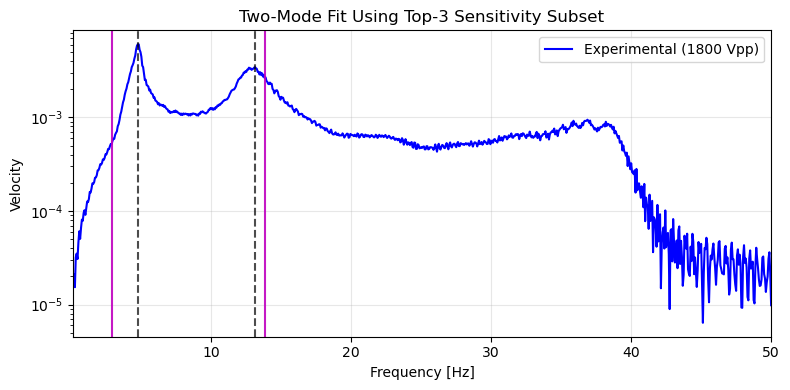

In [65]:
# ------------------------------------------------------------
# Subset calibration: optimize top-ranked influential parameters
# ------------------------------------------------------------
from scipy.optimize import least_squares

if 'fd_rank' not in globals():
    raise RuntimeError('Run the parameter influence study cell first.')
if 'f_exp_targets' not in globals():
    raise RuntimeError('Run the resonance target extraction cell first.')

# Choose top-k from finite-difference ranking
top_k = 3
subset_labels = fd_rank['param'].head(top_k).tolist()

# Map display labels back to tp attribute names
label_to_attr = {
    'hp': 'hp',
    'hs': 'hs',
    'b': 'b',
    'E_s': 'E_s',
    'rho_s': 'rho_s',
    'rho_p': 'rho_p',
    'd31': 'd31',
    'eps_r': 'eps_r',
    'E_p (via s11)': 's11',
}
subset_attrs = [label_to_attr[s] for s in subset_labels if s in label_to_attr]

# Bounds for physical parameters
param_bounds = {
    'hp': (0.05e-3, 0.60e-3),
    'hs': (0.20e-3, 1.50e-3),
    'b': (20e-3, 120e-3),
    'E_s': (0.5e9, 20e9),
    's11': (1.0/80e9, 1.0/5e9),
    'rho_s': (500.0, 3000.0),
    'rho_p': (3000.0, 9000.0),
    'd31': (-5e-10, -1e-11),
    'eps_r': (300.0, 3000.0),
}

# Build optimization vectors
x0 = np.array([getattr(tp, a).item() for a in subset_attrs], dtype=float)
lb = np.array([param_bounds[a][0] for a in subset_attrs], dtype=float)
ub = np.array([param_bounds[a][1] for a in subset_attrs], dtype=float)

target_subset = np.asarray(f_exp_targets, dtype=float)
base_snapshot = {a: getattr(tp, a).detach().clone() for a in subset_attrs}

def set_subset(x):
    with torch.no_grad():
        for i, a in enumerate(subset_attrs):
            getattr(tp, a).fill_(float(x[i]))

def get_model_freq2():
    return fe(n_modes=2)['freq'][:2].detach().cpu().numpy()

def resid_subset(x):
    set_subset(x)
    f_model = get_model_freq2()
    return (f_model - target_subset) / target_subset

res_subset = least_squares(
    resid_subset,
    x0=x0,
    bounds=(lb, ub),
    method='trf',
    xtol=1e-12,
    ftol=1e-12,
    gtol=1e-12,
    max_nfev=400,
    verbose=1,
 )

x_opt = res_subset.x
set_subset(x_opt)
f_opt_subset = get_model_freq2()

print(f'Subset labels used: {subset_labels}')
print(f'Subset attrs used : {subset_attrs}')
print('Optimized parameter values:')
for i, a in enumerate(subset_attrs):
    print(f'  {a:>6s} = {x_opt[i]:.6e}')

print('\nTwo-mode fit (subset calibration):')
print(f'  Experimental [Hz]: {target_subset}')
print(f'  Model [Hz]      : {f_opt_subset}')
print(f'  Abs error [Hz]  : {np.abs(f_opt_subset - target_subset)}')

# Visual check
plt.figure(figsize=(8, 4))
plt.semilogy(f_band, v_band, 'b-', lw=1.5, label=f'Experimental ({preferred_sheet})')
for fx in target_subset:
    plt.axvline(fx, color='k', ls='--', alpha=0.7)
for fm in f_opt_subset:
    plt.axvline(fm, color='m', ls='-', alpha=0.9)
plt.xlim([f0, f1])
plt.xlabel('Frequency [Hz]')
plt.ylabel('Velocity')
plt.title(f'Two-Mode Fit Using Top-{top_k} Sensitivity Subset')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [78]:
zeta_dict

{1: 0.02,
 2: 0.025,
 3: 0.03,
 4: 0.007,
 5: 0.0075,
 6: 0.0085,
 7: 0.008,
 8: 0.007,
 9: 0.007,
 10: 0.0075,
 11: 0.008,
 12: 0.009,
 13: 0.01,
 14: 0.012,
 15: 0.014,
 16: 0.014,
 17: 0.013,
 18: 0.013,
 19: 0.015,
 20: 0.023,
 21: 0.024,
 22: 0.025,
 'rest': 0.4,
 '1': 0.5}

Initialization check:
  first x_start [mm]: 0.1000  (target: 0.0000)
  all gaps > 0: True
  min gap [mm]: 3.000
  L [m]: 0.30000
  EI finite: True
  rhoA finite: True

Gradient check (joint):
  Initial f [Hz]: [ 3.13382933 14.2984508 ]
  Initial J: 1.2376e-01
  ||d/d(raw_first)||: 3.4548e-04
  ||d/d(raw_sections)||: 5.9531e-02
  |d/d(raw_L)|: 8.2757e-02
  |d/dhs|: 5.0683e+02
  |d/drho_s|: 2.5509e-04
  |d/db|: 1.9754e+00

Optimization trace (joint):
  it=  0  J=1.238e-01  f1=  3.134Hz  f2= 14.298Hz  L=0.3000m  hs=1.500mm  rho=1190.0  b=99.0mm
  it= 40  J=1.203e-01  f1=  3.108Hz  f2= 13.477Hz  L=0.3005m  hs=0.498mm  rho=1190.0  b=93.7mm
  it= 80  J=7.407e-02  f1=  3.558Hz  f2= 14.510Hz  L=0.3005m  hs=0.510mm  rho=1190.0  b=67.8mm
  it=120  J=7.900e-03  f1=  4.364Hz  f2= 13.600Hz  L=0.3004m  hs=0.482mm  rho=1190.0  b=29.6mm
  it=160  J=2.275e-05  f1=  4.730Hz  f2= 13.154Hz  L=0.3004m  hs=0.476mm  rho=1190.0  b=22.1mm
  it=199  J=5.870e-08  f1=  4.751Hz  f2= 13.122Hz  L=0.3004m  hs=0.475mm

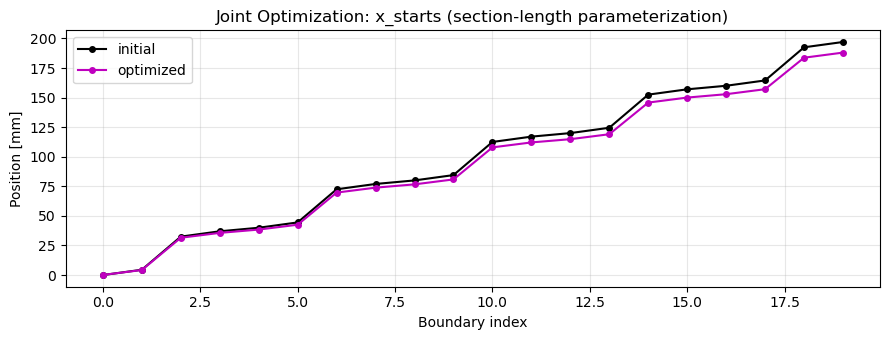

In [71]:

# ------------------------------------------------------------
# Joint optimization: x_starts (section-length parameterization),
# beam length L, and material parameters (hs, rho_s, b)
# ------------------------------------------------------------
# Monotonicity guarantee:
#   Parameterize as  [first_pos, gap_1, gap_2, ..., gap_{n-1}]
#   where every entry > 0 via softplus.
#   x_starts[k] = first_pos + sum(gaps[:k])
#   Ordering is guaranteed structurally — no penalty needed.
# ------------------------------------------------------------
import torch.nn.functional as F

if 'f_exp_targets' in globals():
    target_joint_np = np.asarray(f_exp_targets, dtype=float)
else:
    target_joint_np = np.array([4.75, 13.125], dtype=float)
target_joint = torch.tensor(target_joint_np, dtype=tp.dtype)

# Reference tensors (redefine here so cell is self-contained)
x_mid_ref_t = torch.tensor(x_mid, dtype=tp.dtype)
L_ref_t     = torch.tensor(float(L), dtype=tp.dtype)

# ---- Section-length parameterization ----
x_starts_arr  = np.asarray(x_starts, dtype=float)
first_pos_init = float(x_starts_arr[0])   # may be 0.0
sec_lens_init  = np.diff(x_starts_arr).astype(float)   # all > 0
min_gap = 1e-3   # minimum gap between consecutive starts [m]

def softplus_inv(y_tensor):
    """Numerically stable inverse of softplus for y > 0."""
    y = y_tensor.clone()
    return torch.where(y > 20.0, y, torch.log(torch.expm1(y.clamp(min=1e-9))))

# First position: softplus(raw_first) >= 0, no lower bound needed
# If first_pos_init == 0 we initialise raw_first so softplus ≈ 1e-4 m (near zero)
_fp0 = max(first_pos_init, 1e-4)
raw_first = torch.nn.Parameter(
    softplus_inv(torch.tensor(_fp0, dtype=tp.dtype))
)

# Section lengths: softplus(raw_sections) + min_gap > min_gap
# All sec_lens_init are confirmed > min_gap
raw_sections = torch.nn.Parameter(
    softplus_inv(torch.tensor(sec_lens_init - min_gap, dtype=tp.dtype))
)

# ---- Trainable L  (constrained: L > last x_start + clearance) ----
L_min_j = torch.tensor(float(x_starts_arr[-1]) + 5e-3, dtype=tp.dtype)
raw_L_j = torch.nn.Parameter(
    softplus_inv(L_ref_t - L_min_j)
)

# ---- Restore tp to reference values ----
with torch.no_grad():
    tp.hs.fill_(h_s)
    tp.rho_s.fill_(rho_s)
    tp.b.fill_(b_s)

for p in tp.parameters():
    p.requires_grad_(False)

mat_bounds = {
    'hs':    (0.20e-3, 1.50e-3),
    'rho_s': (500.0,   3000.0),
    'b':     (20e-3,   120e-3),
}
for name in mat_bounds:
    getattr(tp, name).requires_grad_(True)

# ---- Parameter recovery helpers ----
def get_x_starts():
    """Strictly ordered x_starts recovered from section lengths."""
    first = F.softplus(raw_first)                      # always > 0
    gaps  = min_gap + F.softplus(raw_sections)         # always > min_gap
    return torch.cat([first.view(1), first + torch.cumsum(gaps, dim=0)])

def get_L():
    return L_min_j + F.softplus(raw_L_j)

# ---- Per-region EI/rhoA as differentiable functions of tp ----
def region_property_scalars(tp_local):
    E_p_t = 1.0 / tp_local.s11
    EI_sub  = tp_local.b * tp_local.E_s * tp_local.hs ** 3 / 12.0
    rhoA_sub = tp_local.b * tp_local.rho_s * tp_local.hs
    EI_kap, rhoA_kap = layered_EI_rhoA_torch(
        [tp_local.E_s, E_k_t], [tp_local.rho_s, rho_k_t],
        [tp_local.hs, h_k_t],  [tp_local.b, b_k_t],
    )
    EI_pie, rhoA_pie = layered_EI_rhoA_torch(
        [tp_local.E_s, E_k_t, E_p_t], [tp_local.rho_s, rho_k_t, tp_local.rho_p],
        [tp_local.hs,  h_k_t, tp_local.hp],
        [tp_local.b,   b_k_t, torch.tensor(b_p, dtype=tp_local.dtype)],
    )
    return {'substrate': (EI_sub, rhoA_sub),
            'kapton':    (EI_kap, rhoA_kap),
            'piezo':     (EI_pie, rhoA_pie)}

tau_j = torch.tensor(8e-4, dtype=tp.dtype)

# ---- Differentiable element property function ----
def elem_property_fn_joint(tp_local):
    L_now     = get_L()
    xs_now    = get_x_starts()
    x_mid_now = x_mid_ref_t * (L_now / L_ref_t)   # stretch mesh with L
    tau_now   = tau_j * (L_now / L_ref_t)

    # Soft region membership: W[elem, region] via sigmoid gates
    ends  = torch.cat([xs_now[1:], L_now.view(1)])
    left  = torch.sigmoid((x_mid_now[:, None] - xs_now[None, :]) / tau_now)
    right = torch.sigmoid((x_mid_now[:, None] - ends[None, :])   / tau_now)
    W     = torch.clamp(left - right, min=0.0)
    W     = W / (W.sum(dim=1, keepdim=True) + 1e-12)

    prop       = region_property_scalars(tp_local)
    EI_regs    = torch.stack([prop[lbl][0] for lbl in region_sequence])
    rhoA_regs  = torch.stack([prop[lbl][1] for lbl in region_sequence])
    return W @ EI_regs, W @ rhoA_regs

fe_joint = PiezoBeamFE_Torch(tp, geometry=geom, elem_property_fn=elem_property_fn_joint)

# ---- Objective ----
def objective_joint():
    L_now  = get_L()
    f2_raw = fe_joint(n_modes=2)['freq'][:2]
    f2     = f2_raw * (L_ref_t / L_now) ** 2          # Euler-Bernoulli L-scaling

    J = torch.sum(((f2 - target_joint) / target_joint) ** 2)

    # Soft bound penalties on material params
    pen_mat = torch.zeros((), dtype=tp.dtype)
    for name, (lo, hi) in mat_bounds.items():
        v = getattr(tp, name)
        pen_mat = pen_mat + torch.relu(torch.tensor(lo, dtype=tp.dtype) - v) ** 2
        pen_mat = pen_mat + torch.relu(v - torch.tensor(hi, dtype=tp.dtype)) ** 2

    # L must stay comfortably above last x_start
    xs     = get_x_starts()
    pen_L  = torch.relu(xs[-1] + 3e-3 - L_now) ** 2
    return J + 1e5 * pen_mat + 1e5 * pen_L, J, f2, L_now, xs

# ---- Sanity check: verify no NaN/Inf in initial K/M ----
with torch.no_grad():
    xs_init  = get_x_starts().numpy()
    L_init   = get_L().item()
    print('Initialization check:')
    print(f'  first x_start [mm]: {xs_init[0]*1e3:.4f}  (target: {first_pos_init*1e3:.4f})')
    print(f'  all gaps > 0: {bool(np.all(np.diff(xs_init) > 0))}')
    print(f'  min gap [mm]: {np.diff(xs_init).min()*1e3:.3f}')
    print(f'  L [m]: {L_init:.5f}')
    EI_test, rhoA_test = elem_property_fn_joint(tp)
    print(f'  EI finite: {torch.isfinite(EI_test).all().item()}')
    print(f'  rhoA finite: {torch.isfinite(rhoA_test).all().item()}')

# ---- Gradient check ----
loss0, J0, f0j, L0j, xs0 = objective_joint()
loss0.backward()
print('\nGradient check (joint):')
print(f'  Initial f [Hz]: {f0j.detach().cpu().numpy()}')
print(f'  Initial J: {J0.item():.4e}')
print(f'  ||d/d(raw_first)||: {raw_first.grad.abs().item():.4e}')
print(f'  ||d/d(raw_sections)||: {raw_sections.grad.norm().item():.4e}')
print(f'  |d/d(raw_L)|: {raw_L_j.grad.abs().item():.4e}')
for name in mat_bounds:
    g = getattr(tp, name).grad
    print(f'  |d/d{name}|: {g.abs().item() if g is not None else 0:.4e}')

# ---- Joint optimization ----
trainable = [raw_first, raw_sections, raw_L_j,
             tp.hs, tp.rho_s, tp.b]
opt_joint = torch.optim.Adam(trainable, lr=1e-3)

hist_joint = []
for it in range(200):
    opt_joint.zero_grad()
    loss, J, f2, L_now, xs_now = objective_joint()
    loss.backward()
    opt_joint.step()

    with torch.no_grad():
        for name, (lo, hi) in mat_bounds.items():
            getattr(tp, name).clamp_(min=lo, max=hi)

    if (it % 40 == 0) or (it == 199):
        hist_joint.append((
            it, loss.item(), J.item(),
            f2[0].item(), f2[1].item(), L_now.item(),
            tp.hs.item()*1e3, tp.rho_s.item(), tp.b.item()*1e3,
        ))

# ---- Final diagnostics ----
with torch.no_grad():
    _, _, f_final, L_final, xs_final = objective_joint()
    xs_final_np = xs_final.cpu().numpy()
    f_final_np  = f_final.cpu().numpy()
    L_final_val = L_final.item()

print('\nOptimization trace (joint):')
for rec in hist_joint:
    it, ls, jv, f1v, f2v, Lv, hsv, rhov, bv = rec
    print(f'  it={it:3d}  J={jv:.3e}  f1={f1v:7.3f}Hz  f2={f2v:7.3f}Hz'
          f'  L={Lv:.4f}m  hs={hsv:.3f}mm  rho={rhov:.1f}  b={bv:.1f}mm')

print('\nSection-length monotonicity check:')
gaps = np.diff(xs_final_np)
print(f'  Strictly increasing: {bool(np.all(gaps > 0.0))}')
print(f'  Section lengths [mm]: {np.round(gaps*1e3, 2)}')
print(f'  Min section [mm]: {gaps.min()*1e3:.3f}')

print('\nFinal result:')
print(f'  Experimental [Hz]: {target_joint_np}')
print(f'  Model [Hz]      : {f_final_np}')
print(f'  Abs error [Hz]  : {np.abs(f_final_np - target_joint_np)}')
print(f'  Optimized L [m]: {L_final_val:.5f}')
for name in mat_bounds:
    print(f'  Optimized {name}: {getattr(tp, name).item():.4e}')

# ---- Plot ----
plt.figure(figsize=(9, 3.5))
plt.plot(np.arange(len(x_starts_arr)), x_starts_arr*1e3, 'ko-', ms=4, label='initial')
plt.plot(np.arange(len(xs_final_np)),  xs_final_np*1e3,  'mo-', ms=4, label='optimized')
plt.xlabel('Boundary index')
plt.ylabel('Position [mm]')
plt.title('Joint Optimization: x_starts (section-length parameterization)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


FRF sweep: 100%|██████████| 500/500 [00:03<00:00, 140.00it/s]


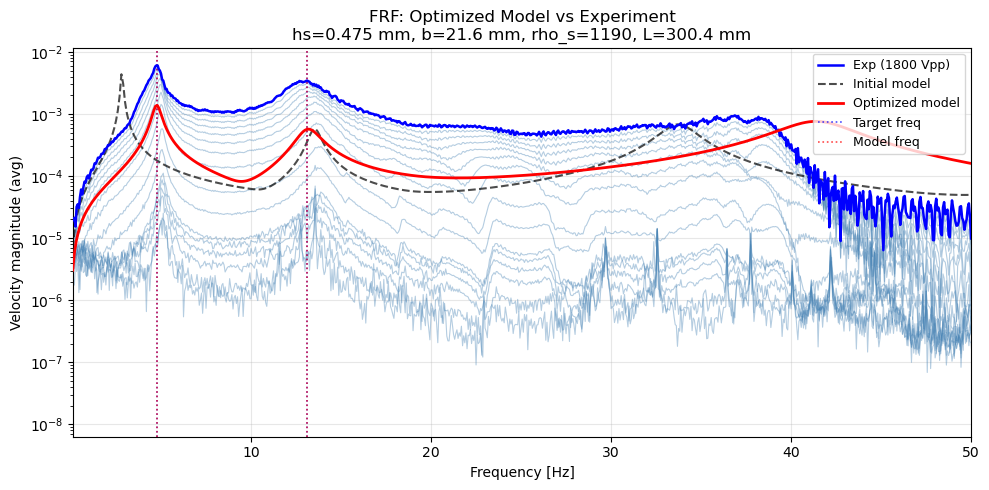

Resonance comparison:
  Mode 1: target=4.750 Hz  model=4.752 Hz  err=0.0017 Hz
  Mode 2: target=13.125 Hz  model=13.126 Hz  err=0.0015 Hz


In [87]:

# ------------------------------------------------------------
# FRF of optimized model overlaid on experimental data
# ------------------------------------------------------------
# Build ODE system from the optimized fe_joint model


ode_opt = build_ode_system_compat(
    fe=fe_joint,
    j_exc=j_exc,
    R_c=1e3,
    K_p=0.0,
    K_i=0.0,
    K_c=0.0,
    v_exc=v_exc,
    freq_domain_amps=weights_complex,
    c_alpha=0.0,
    c_beta=0.0,
    zeta_dict={'1': 0.04, '2': 0.12, 'rest':0.05},
)
frf_opt = FE_helpers.frf_sweep(ode_opt, omega_fd)
vel_opt = np.mean(np.abs(frf_opt['u_dot']), axis=1)

fig, ax = plt.subplots(figsize=(10, 5))

# Experimental data (all sheets, light lines)
for sheet_name in xls.sheet_names:
    df_s = pd.read_excel(excel_path, sheet_name=sheet_name, usecols=[0, 1])
    fe_s = pd.to_numeric(df_s.iloc[:, 0], errors='coerce')
    ve_s = pd.to_numeric(df_s.iloc[:, 1], errors='coerce')
    valid_s = fe_s.notna() & ve_s.notna()
    if valid_s.any():
        ax.semilogy(fe_s[valid_s], ve_s[valid_s], color='steelblue', lw=0.8, alpha=0.4)

# Highlight main experimental sheet
ax.semilogy(f_band, v_band, 'b-', lw=1.8, label=f'Exp ({preferred_sheet})', zorder=3)

# Initial model FRF (before optimization) for comparison
ax.semilogy(freq_fd, vel_fd_torch/10, 'k--', lw=1.5, label='Initial model', alpha=0.7)

# Optimized model FRF
ax.semilogy(freq_fd, vel_opt/10, 'r-', lw=2.0, label='Optimized model', zorder=4)

# Mark target and optimized resonance frequencies
for i, (ft, fm) in enumerate(zip(target_joint_np, f_final_np)):
    ax.axvline(ft, color='b', ls=':', lw=1.2, alpha=0.7, label='Target freq' if i == 0 else None)
    ax.axvline(fm, color='r', ls=':', lw=1.2, alpha=0.7, label='Model freq'  if i == 0 else None)

ax.set_xlim([f0, f1])
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Velocity magnitude (avg)')
ax.set_title('FRF: Optimized Model vs Experiment\n'
             f'hs={tp.hs.item()*1e3:.3f} mm, b={tp.b.item()*1e3:.1f} mm, '
             f'rho_s={tp.rho_s.item():.0f}, L={L_final_val*1e3:.1f} mm')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

print('Resonance comparison:')
for i, (ft, fm) in enumerate(zip(target_joint_np, f_final_np)):
    print(f'  Mode {i+1}: target={ft:.3f} Hz  model={fm:.3f} Hz  err={abs(fm-ft):.4f} Hz')


In [54]:
# ------------------------------------------------------------
# Save config and results (similar structure to original notebook)
# ------------------------------------------------------------
import json
import pickle
from datetime import datetime

save_dir = Path('./sim_dat')
save_dir.mkdir(parents=True, exist_ok=True)

config = {
    'model': 'models_torch.PiezoBeamFE_Torch',
    'beam': {
        'h_s': float(tp.hs.detach().cpu()),
        'h_p': float(tp.hp.detach().cpu()),
        'b': float(tp.b.detach().cpu()),
        'E_s': float(tp.E_s.detach().cpu()),
        'E_p': float((1.0 / tp.s11).detach().cpu()),
        'rho_s': float(tp.rho_s.detach().cpu()),
        'rho_p': float(tp.rho_p.detach().cpu()),
        'd31': float(tp.d31.detach().cpu()),
        'eps_r': float(tp.eps_r.detach().cpu()),
        'w_p': tp.w_p,
        'w_s': tp.w_s,
        'n_patches': tp.n_patches
    },
    'excitation': {
        'A_exc': A_exc.tolist(),
        'phase_exc': phase_exc.tolist(),
        'f0': f0,
        'f1': f1
    }
}

results = {
    'freq_fd': freq_fd,
    'vel_fd': vel_fd,
    'modes_hz': out['freq'].detach().cpu().numpy(),
    'K_red': K_red.detach().cpu().numpy(),
    'M_red': M_red.detach().cpu().numpy(),
    'Gamma_red': Gamma_red.detach().cpu().numpy()
}

payload = {'config': config, 'results': results}

stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
out_file = save_dir / f'arbitrary_placement_torch_{stamp}.pkl'
json_file = save_dir / f'arbitrary_placement_torch_{stamp}.json'

with open(out_file, 'wb') as f:
    pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)

with open(json_file, 'w') as f:
    json.dump(config, f, indent=2)

print(f'Saved: {out_file}')
print(f'Saved: {json_file}')

Saved: sim_dat\arbitrary_placement_torch_20260313_160052.pkl
Saved: sim_dat\arbitrary_placement_torch_20260313_160052.json
